# GraphMERC v2 — ablation-optimized MERC graph network
**Derived from HyFIN-Net (arch21) by applying the verdicts of two ablation campaigns**
(Study 1: component removal, 15 variants · Study 2: M2/M3/M4/M6 option grids, 45 variants).

| Change | Evidence |
|---|---|
| InputLN removed | Study 1 B3: +1.00 wF1 when removed |
| Hypergraph + Multi-Frequency modules removed | A2 +0.47 / A3 +0.59; C3-minimal best Study-1 variant |
| Single graph branch | B5 +0.45 |
| Implicit edges removed | M4: E0 3-seed 0.6860±0.0025 beats every detector variant |
| CrossModalAttn → parameter-free mean fusion | M6: text-anchor worst variant (−2.82 vs mean) |
| **Cross-utterance inter-modal edges added** | **M6 F5: 0.6988±0.0047 (+1.98 vs A0) — largest reliable gain** |
| Alternating inter-FIRST graph schedule | F4a +0.92 vs mean-base; intra-first −0.72 |
| label_smoothing 0.1 → 0.0 (CB weights kept) | M3 grid: smoothing dilutes minority up-weighting |
| CBFC(γ=2, dialogue) → **BCL (global scope)** | M3: BCL-global +0.51; CBFC-dialogue < no-contrastive |
| Modality dropout p=0.15 added | M2 G4: +0.49; only balancing method that helped |
| OGM-GE / AFW / AMW / EACL — excluded | all hurt when measured (−0.97…−2.64) |

Kept (essential per Study 1): **PosEnc** (−2.23 if removed), **speaker embedding** (−1.39),
**contrastive term** (−1.00), **windowed graph** (−0.45), training protocol.

> ⚠️ The three Study-2 winners were each measured on *different* bases. Section 10's
> R1 protocol verifies they compose before any number is trusted.

## 0. Environment

In [1]:
import subprocess, sys, importlib
def _try(mod):
    try:
        importlib.import_module(mod); return True
    except Exception:
        return False
# Kaggle GPU image already ships torch + torch_geometric, but torch_scatter/torch_sparse may be missing.
if not _try('torch_scatter') or not _try('torch_sparse'):
    import torch as _t
    tv = _t.__version__.split('+')[0]
    cu = _t.version.cuda.replace('.', '') if _t.version.cuda else 'cpu'
    url = f'https://data.pyg.org/whl/torch-{tv}+cu{cu}.html'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-index',
                    'torch_scatter', 'torch_sparse', '-f', url], check=False)
    if not _try('torch_geometric'):
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=False)
import torch, torch_geometric
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| pyg', torch_geometric.__version__)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
import os
IS_KAGGLE = os.path.exists('/kaggle/working')
print('Platform: Kaggle' if IS_KAGGLE else 'Platform: local')

torch 2.11.0+cu128 | cuda 12.8 | pyg 2.7.0
GPU: NVIDIA GeForce RTX 3060
Platform: local


In [2]:
import os, pickle, math, random, time, copy, json
from pathlib import Path
from itertools import permutations
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GraphConv, TransformerConv
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax as pyg_softmax, degree
from torch_scatter import scatter_add
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

SEED = 2024
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)


def set_seed(s):
    """Model-training seed (the data split stays on SEED=2024 — both campaigns used it)."""
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


device = cuda


## 1. Config (v2)

In [3]:
# ── Local paths ── edit DATA_ROOT or set env vars when running outside Kaggle ─
_LOCAL_DATA_ROOT = os.environ.get(
    'GRAPHSMILE_DATA',
    str(Path('/mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed')))
_LOCAL_SAVE_DIR  = os.environ.get('HYFIN_SAVE_DIR', './outputs')
# ─────────────────────────────────────────────────────────────────────────────

class Cfg:
    # ---- choose dataset: 'meld' or 'iemocap'
    dataset      = 'iemocap'
    data_root    = ('/kaggle/input/datasets/gilbertstrange/graphsmile-preprocessed/GraphSmile_PreProcessed'
                    if IS_KAGGLE else _LOCAL_DATA_ROOT)
    save_dir     = '/kaggle/working' if IS_KAGGLE else _LOCAL_SAVE_DIR
    @property
    def meld_path(self):    return f'{self.data_root}/meld_multi_features.pkl'
    @property
    def iemocap_path(self): return f'{self.data_root}/iemocap_multi_features.pkl'
    # ---- training (30 ep = the measured protocol of both campaigns; one 60-ep check in R1)
    batch_size_d = {'iemocap': 16, 'meld': 32}
    epochs       = 60
    lr           = 0.0001933493042241848
    weight_decay = 0.003620308715721313
    grad_clip    = 1.0750086590701415
    warmup_epochs = 1
    label_smoothing =  0.11273605484740641        # M3 grid: ls=0.1 dilutes CB minority up-weighting
    cb_weights   = True            # M3 grid: +0.007-0.009 mF1, hap +0.05-0.09
    # ---- model
    hidden       = 512
    n_speakers   = {'iemocap': 2, 'meld': 9}
    n_classes    = {'iemocap': 6, 'meld': 7}
    # ---- graph (v2): SINGLE branch (B5), windowed + cross-utterance inter-modal (F5)
    window       = {'iemocap': (5, 3), 'meld': (7, 4)}   # (past, future)
    gnn_layers   = 3
    gnn_heads    = 2
    schedule     = 'alt_inter_first'   # F5 winner | 'joint' (F5b) | 'alt_intra_first' (loses)
    cross_utt_inter = True             # E3 — the +1.98 component; flag for attribution runs
    dropout      = {'iemocap': 0.33437489710871665, 'meld': 0.5}
    # ---- losses (M3 verdicts)
    beta_cb      = 0.9917243388907966
    contrastive  = 'off'           # 'bcl' (global, winner) | 'cbfc' (gamma=1 fallback) | 'off'
    con_mu       = 0.4618743132942995
    con_temp     = 0.7987025866338576
    cbfc_gamma   = 1.0             # M3 sweep: gamma=1 > gamma=0 > gamma=2
    # ---- training-side balance (M2 verdict)
    mod_dropout_p = 0.2857674160315858     # only balancing method that helped (G4 +0.49)
    val_frac     = 0.1
    log_every    = 100
    @property
    def batch_size(self): return self.batch_size_d[self.dataset]

cfg = Cfg()
os.makedirs(cfg.save_dir, exist_ok=True)
print(f'data_root: {cfg.data_root}')
print(f'save_dir : {cfg.save_dir}')


data_root: /mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed
save_dir : ./outputs


## 2. Dataset — robust loader for GraphSmile preprocessed pickles

GraphSmile's preprocessed pickle follows the standard MMGCN/M3Net layout:
```
(videoIDs, videoSpeakers, videoLabels, videoText, videoAudio, videoVisual,
 videoSentence, trainVid, testVid[, _])
```
Each `video*` is `dict[vid] -> list/ndarray` indexed by utterance position.

In [4]:
def _load_pickle(path):
    with open(path, 'rb') as f:
        try:
            return pickle.load(f, encoding='latin1')
        except TypeError:
            f.seek(0); return pickle.load(f)

def parse_graphsmile_pickle(path, dataset):
    """Supports all three GraphSmile preprocessed layouts:
      9  : IEMOCAPDataset_BERT4 (single videoText)
      12 : IEMOCAPDataset_BERT  (videoText0..3)
      13/14 : MELDDataset_BERT  (videoSentiments + videoText0..3 + trailing _)
    For multi-layer text we average the 4 RoBERTa layers (M3Net `(r1+r2+r3+r4)/4`).
    """
    obj = _load_pickle(path)
    assert isinstance(obj, (tuple, list)), f'unexpected pickle type {type(obj)}'
    n = len(obj)
    if n == 9:
        (videoIDs, videoSpeakers, videoLabels,
         videoText, videoAudio, videoVisual, videoSentence,
         trainVid, testVid) = obj
        text_dict = videoText
    elif n in (12,):
        (videoIDs, videoSpeakers, videoLabels,
         vT0, vT1, vT2, vT3,
         videoAudio, videoVisual, videoSentence,
         trainVid, testVid) = obj
        text_dict = {vid: (np.asarray(vT0[vid], dtype=np.float32)
                          + np.asarray(vT1[vid], dtype=np.float32)
                          + np.asarray(vT2[vid], dtype=np.float32)
                          + np.asarray(vT3[vid], dtype=np.float32)) / 4.0
                     for vid in vT0.keys()}
    elif n in (13, 14):
        (videoIDs, videoSpeakers, videoLabels, videoSentiments,
         vT0, vT1, vT2, vT3,
         videoAudio, videoVisual, videoSentence,
         trainVid, testVid, *rest) = obj
        text_dict = {vid: (np.asarray(vT0[vid], dtype=np.float32)
                          + np.asarray(vT1[vid], dtype=np.float32)
                          + np.asarray(vT2[vid], dtype=np.float32)
                          + np.asarray(vT3[vid], dtype=np.float32)) / 4.0
                     for vid in vT0.keys()}
    else:
        raise ValueError(f'unsupported pickle layout: {n} fields')

    sample_vid = next(iter(text_dict))
    Dt = int(np.asarray(text_dict[sample_vid]).shape[-1])
    Da = int(np.asarray(videoAudio[sample_vid]).shape[-1])
    Dv = int(np.asarray(videoVisual[sample_vid]).shape[-1])
    print(f'  layout={n} fields  dims t/a/v = {Dt}/{Da}/{Dv}  train={len(trainVid)}, test={len(testVid)}')
    return dict(text=text_dict, audio=videoAudio, visual=videoVisual,
                labels=videoLabels, speakers=videoSpeakers, sentences=videoSentence,
                trainVid=list(trainVid), testVid=list(testVid))

def _speaker_to_idx(spk, dataset):
    if dataset == 'iemocap':
        out = []
        for s in spk:
            if isinstance(s, (str, bytes)):
                ss = s.decode() if isinstance(s, bytes) else s
                out.append({'M': 0, 'F': 1}.get(ss, 0))
            else:
                out.append(int(s))
        return out
    arr = np.asarray(spk)
    if arr.ndim == 2:                # MELD: one-hot rows
        return arr.argmax(-1).tolist()
    return arr.astype(int).tolist()

class MERCDataset(Dataset):
    def __init__(self, raw, vids, dataset):
        self.raw = raw; self.vids = vids; self.dataset = dataset
    def __len__(self): return len(self.vids)
    def __getitem__(self, idx):
        vid = self.vids[idx]
        t = np.asarray(self.raw['text'][vid],   dtype=np.float32)
        a = np.asarray(self.raw['audio'][vid],  dtype=np.float32)
        v = np.asarray(self.raw['visual'][vid], dtype=np.float32)
        y = np.asarray(self.raw['labels'][vid], dtype=np.int64)
        spk = _speaker_to_idx(self.raw['speakers'][vid], self.dataset)
        assert t.ndim == 2 and a.ndim == 2 and v.ndim == 2, (
            f'vid={vid} shapes t{t.shape} a{a.shape} v{v.shape}')
        return {
            'text': torch.from_numpy(t), 'audio': torch.from_numpy(a),
            'visual': torch.from_numpy(v), 'label': torch.from_numpy(y),
            'speaker': torch.tensor(spk, dtype=torch.long),
            'length': int(t.shape[0]),
        }

def pad_collate(batch):
    B = len(batch)
    L = max(s['length'] for s in batch)
    Dt = batch[0]['text'].shape[-1]
    Da = batch[0]['audio'].shape[-1]
    Dv = batch[0]['visual'].shape[-1]
    text = torch.zeros(B, L, Dt)
    audio = torch.zeros(B, L, Da)
    visual = torch.zeros(B, L, Dv)
    spk = torch.zeros(B, L, dtype=torch.long)
    lens = torch.zeros(B, dtype=torch.long)
    labels = []
    for i, s in enumerate(batch):
        n = s['length']
        text[i, :n]   = s['text']
        audio[i, :n]  = s['audio']
        visual[i, :n] = s['visual']
        spk[i, :n]    = s['speaker']
        lens[i]       = n
        labels.append(s['label'])
    return {'text': text, 'audio': audio, 'visual': visual,
            'speaker': spk, 'lengths': lens, 'labels': torch.cat(labels)}

# --- load and probe ---
path = cfg.meld_path if cfg.dataset == 'meld' else cfg.iemocap_path
print(f'loading {path}')
raw = parse_graphsmile_pickle(path, dataset=cfg.dataset)
print('train vids:', len(raw['trainVid']), 'test vids:', len(raw['testVid']))

probe_dims = []
for vid in list(raw['trainVid'])[:5]:
    t = np.asarray(raw['text'][vid]); a = np.asarray(raw['audio'][vid]); v = np.asarray(raw['visual'][vid])
    assert t.ndim == a.ndim == v.ndim == 2, f'vid={vid} non-2D features: t{t.shape} a{a.shape} v{v.shape}'
    probe_dims.append((t.shape[-1], a.shape[-1], v.shape[-1]))
assert len(set(probe_dims)) == 1, f'inconsistent feature dims across dialogues: {set(probe_dims)}'
D_T, D_A, D_V = probe_dims[0]
print(f'consistent feature dims t/a/v = {D_T}/{D_A}/{D_V}')


loading /mnt/Work/ML/Thesis/WACV/data/GraphSmile_PreProcessed/iemocap_multi_features.pkl
  layout=12 fields  dims t/a/v = 1024/1582/342  train=120, test=31
train vids: 120 test vids: 31
consistent feature dims t/a/v = 1024/1582/342


In [5]:
# train/val/test split (no official val on IEMOCAP/MELD GraphSmile → carve from train)
train_all = list(raw['trainVid'])
rng = random.Random(SEED); rng.shuffle(train_all)
n_val = max(1, int(len(train_all) * cfg.val_frac))
val_vids = train_all[:n_val]
train_vids = train_all[n_val:]
test_vids = list(raw['testVid'])

train_set = MERCDataset(raw, train_vids, cfg.dataset)
val_set   = MERCDataset(raw, val_vids,   cfg.dataset)
test_set  = MERCDataset(raw, test_vids,  cfg.dataset)

train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True,
                          collate_fn=pad_collate, num_workers=(2 if IS_KAGGLE else min(4, os.cpu_count() or 1)), pin_memory=IS_KAGGLE)
val_loader   = DataLoader(val_set,   batch_size=cfg.batch_size, shuffle=False,
                          collate_fn=pad_collate, num_workers=(2 if IS_KAGGLE else min(4, os.cpu_count() or 1)), pin_memory=IS_KAGGLE)
test_loader  = DataLoader(test_set,  batch_size=cfg.batch_size, shuffle=False,
                          collate_fn=pad_collate, num_workers=(2 if IS_KAGGLE else min(4, os.cpu_count() or 1)), pin_memory=IS_KAGGLE)
print(f'split: train={len(train_set)}  val={len(val_set)}  test={len(test_set)}')

# class counts on train for class-balanced losses
class_counts = np.zeros(cfg.n_classes[cfg.dataset], dtype=np.int64)
for vid in train_vids:
    for y in raw['labels'][vid]:
        class_counts[int(y)] += 1
print('train class counts:', class_counts.tolist())

split: train=108  val=12  test=31
train class counts: [474, 763, 1200, 814, 711, 1267]


## 3. Unimodal Encoder (v2)
**Change vs arch21: `InputLN` removed** (Study 1 B3: removing the masked per-dialogue
LayerNorm *improved* wF1 by +1.00 and hap by +0.054 — the GraphSmile pickle features
are already utterance-normalized; per-dialogue whitening destroyed cross-dialogue
intensity information). PosEnc and the speaker embedding are the two most load-bearing
components in the whole study (−2.23 / −1.39 when removed) — kept.

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d]
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class UnimodalEncoderV2(nn.Module):
    """arch21 UnimodalEncoder minus InputLN (Study 1 B3 verdict)."""
    def __init__(self, d_t, d_a, d_v, d_h, n_speakers, dropout=0.5):
        super().__init__()
        self.t_proj = nn.Linear(d_t, d_h)
        self.pe     = PositionalEncoding(d_h)
        self.t_enc  = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_h, nhead=4, dim_feedforward=d_h,
                                       dropout=dropout, activation='gelu', batch_first=True),
            num_layers=1)
        self.a_proj = nn.Sequential(nn.Linear(d_a, d_h), nn.ReLU(), nn.Dropout(dropout))
        self.v_proj = nn.Sequential(nn.Linear(d_v, d_h), nn.ReLU(), nn.Dropout(dropout))
        self.spk    = nn.Embedding(n_speakers, d_h)

    def forward(self, text, audio, visual, spk, lengths):
        B, L, _ = text.shape
        mask = torch.arange(L, device=text.device)[None] >= lengths[:, None]  # True = pad
        ht = self.t_enc(self.pe(self.t_proj(text)), src_key_padding_mask=mask)
        ha = self.a_proj(audio)
        hv = self.v_proj(visual)
        s = self.spk(spk)
        return ht + s, ha + s, hv + s, mask


## 4. Graph construction helpers (unchanged)

In [7]:
def flatten_batch(ht, ha, hv, lengths):
    """Return list of per-dialogue stacked node features [3L, H] and a global node tensor.
    Node ordering per dialogue: [L text nodes, L audio nodes, L visual nodes].
    """
    feats = []
    offsets = []
    cur = 0
    for b, n in enumerate(lengths.tolist()):
        t = ht[b, :n]; a = ha[b, :n]; v = hv[b, :n]
        feats.append(torch.cat([t, a, v], dim=0))
        offsets.append(cur)
        cur += 3 * n
    return torch.cat(feats, dim=0), offsets  # [N_total, H]

def unflatten_batch(flat, lengths, offsets):
    """Inverse of flatten_batch. Returns three padded tensors aligned with input order."""
    B = len(lengths)
    L = int(lengths.max().item())
    H = flat.shape[-1]
    ht = flat.new_zeros(B, L, H); ha = flat.new_zeros(B, L, H); hv = flat.new_zeros(B, L, H)
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]
        ht[b, :n] = flat[o:o+n]
        ha[b, :n] = flat[o+n:o+2*n]
        hv[b, :n] = flat[o+2*n:o+3*n]
    return ht, ha, hv

def angular_weight(x, edge_index):
    """a_ij = 1 - arccos(cos)/pi  in [0,1] from ConxGNN. Stable."""
    src, dst = edge_index
    xs = F.normalize(x[src], dim=-1); xd = F.normalize(x[dst], dim=-1)
    cos = (xs * xd).sum(-1).clamp(-1 + 1e-6, 1 - 1e-6)
    return 1.0 - torch.arccos(cos) / math.pi

## 5. Graph (v2) — windowed heterogeneous graph with cross-utterance inter-modal edges
Replaces the IGM/HM/MF triplet with ONE graph block over two edge sets:

- **E_intra** — within-modality window edges (past `p`, future `f`); directed in-edges,
  de-duplicated vs arch21 (whose past+future loops appended every pair twice).
- **E_inter** — cross-modal: same-utterance pairs (E2, as before) **plus
  cross-utterance pairs within the window (E3)** — the F5 component, the largest
  reliable gain in either campaign (3-seed 0.6988±0.0047, +1.98 vs A0). Independently
  corroborates GraphSmile's (TPAMI 2025) claim that same-utterance-only cross-modal
  graphs miss inter-utterance heterogeneous cues.
- **Schedule** — `alt_inter_first` (F4a; the reverse order loses to mean fusion).
  `joint` = F5b fallback (≈F5, simpler).
- No implicit edges (M4: E0 wins confirmation with half the variance).

In [8]:
def build_graph_v2(lengths, offsets, p_window, f_window,
                   cross_utt_inter=True, device='cpu'):
    """Returns (edge_index_inter, edge_index_intra) over the flattened node tensor.
    Node order per dialogue: [n text | n audio | n visual] (flatten_batch)."""
    src_i, dst_i = [], []   # inter-modal (E2 same-utt + E3 cross-utt)
    src_a, dst_a = [], []   # intra-modal window (E1)
    for b, n in enumerate(lengths.tolist()):
        o = offsets[b]
        idx = [torch.arange(n, device=device) + o,           # text block
               torch.arange(n, device=device) + o + n,       # audio block
               torch.arange(n, device=device) + o + 2 * n]   # visual block
        grid = torch.arange(n, device=device)
        # ---- E2: same-utterance cross-modal (bidirectional)
        for x in range(3):
            for y in range(x + 1, 3):
                src_i += [idx[x], idx[y]]; dst_i += [idx[y], idx[x]]
        # ---- E3: cross-utterance cross-modal within window (directed in-edges)
        if cross_utt_inter:
            for x in range(3):
                for y in range(3):
                    if x == y:
                        continue
                    for shift in range(1, p_window + 1):       # from y's past into x_i
                        m = grid >= shift
                        if m.any():
                            src_i.append(idx[y][m] - shift); dst_i.append(idx[x][m])
                    for shift in range(1, f_window + 1):       # from y's future into x_i
                        m = (grid + shift) < n
                        if m.any():
                            src_i.append(idx[y][m] + shift); dst_i.append(idx[x][m])
        # ---- E1: intra-modal window (directed in-edges, de-duplicated)
        for k in range(3):
            for shift in range(1, p_window + 1):
                m = grid >= shift
                if m.any():
                    src_a.append(idx[k][m] - shift); dst_a.append(idx[k][m])
            for shift in range(1, f_window + 1):
                m = (grid + shift) < n
                if m.any():
                    src_a.append(idx[k][m] + shift); dst_a.append(idx[k][m])
    def _stack(s, d):
        if len(s) == 0:
            return torch.zeros(2, 0, dtype=torch.long, device=device)
        return torch.stack([torch.cat(s), torch.cat(d)], dim=0)
    return _stack(src_i, dst_i), _stack(src_a, dst_a)


class GraphBlockV2(nn.Module):
    """Single-branch TransformerConv stack with an inter/intra layer schedule.
    Keeps arch21's relational prior: angular-similarity edge weight as 1-D edge_attr,
    gated against learned attention via beta=True."""
    def __init__(self, d, n_layers, heads=4, dropout=0.1, schedule='alt_inter_first'):
        super().__init__()
        assert d % heads == 0, f'hidden {d} not divisible by heads {heads}'
        self.schedule = schedule
        self.convs = nn.ModuleList([
            TransformerConv(d, d // heads, heads=heads, concat=True,
                            beta=True, dropout=dropout, edge_dim=1)
            for _ in range(n_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d) for _ in range(n_layers)])

    def forward(self, x, e_inter, w_inter, e_intra, w_intra):
        if self.schedule == 'joint':
            e_all = torch.cat([e_inter, e_intra], dim=1)
            w_all = torch.cat([w_inter, w_intra], dim=0)
        h = x
        for li, (conv, ln) in enumerate(zip(self.convs, self.norms)):
            if self.schedule == 'joint':
                ei, ew = e_all, w_all
            elif self.schedule == 'alt_intra_first':
                ei, ew = (e_intra, w_intra) if li % 2 == 0 else (e_inter, w_inter)
            else:  # 'alt_inter_first' — the F5 winner
                ei, ew = (e_inter, w_inter) if li % 2 == 0 else (e_intra, w_intra)
            h = ln(F.relu(conv(h, ei, ew.unsqueeze(-1))) + h)
        return h


## 6. Fusion (v2) — parameter-free mean + classifier
M6 verdict: the mean beat **every** learned fusion at the 30-epoch budget
(text-anchor −2.82, pairwise −1.35, gated −1.52). The classifier input shrinks
3d→d (the HM/MF zero-blocks are gone). A 60-epoch re-test of learned fusion is
queued in the R-protocol before the final lock.

In [9]:
class Classifier(nn.Module):
    def __init__(self, d_in, n_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_in // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_in // 2, n_classes))
    def forward(self, z): return self.net(z)


## 7. GraphMERC v2 assembly
encoder → (train-time modality dropout p=0.15, M2-G4) → flatten → GraphBlockV2
(alt inter-first, cross-utt inter edges) → unflatten → mean fusion → classifier.
`z` (penultimate, [N, d]) feeds the global-scope contrastive loss.

In [10]:
class GraphMERCv2(nn.Module):
    def __init__(self, cfg, d_t, d_a, d_v):
        super().__init__()
        d = cfg.hidden; ds = cfg.dataset
        self.cfg = cfg
        self.encoder = UnimodalEncoderV2(d_t, d_a, d_v, d,
                                         cfg.n_speakers[ds], cfg.dropout[ds])
        self.graph = GraphBlockV2(d, cfg.gnn_layers, heads=cfg.gnn_heads,
                                  dropout=cfg.dropout[ds], schedule=cfg.schedule)
        self.clf = Classifier(d, cfg.n_classes[ds], cfg.dropout[ds])

    def _modality_dropout(self, ht, ha, hv):
        """M2-G4: with prob p per dialogue, zero ONE stream (train only)."""
        p = self.cfg.mod_dropout_p
        if not self.training or p <= 0:
            return ht, ha, hv
        B = ht.size(0)
        drop  = torch.rand(B, device=ht.device) < p          # which dialogues
        which = torch.randint(0, 3, (B,), device=ht.device)  # which stream
        streams = [ht.clone(), ha.clone(), hv.clone()]
        for m in range(3):
            sel = drop & (which == m)
            if sel.any():
                streams[m][sel] = 0.0
        return streams[0], streams[1], streams[2]

    def _features(self, batch):
        text   = batch['text'].to(device)
        audio  = batch['audio'].to(device)
        visual = batch['visual'].to(device)
        spk    = batch['speaker'].to(device)
        lens   = batch['lengths'].to(device)
        ht, ha, hv, key_pad_mask = self.encoder(text, audio, visual, spk, lens)
        ht, ha, hv = self._modality_dropout(ht, ha, hv)
        flat, offsets = flatten_batch(ht, ha, hv, lens)
        p_w, f_w = self.cfg.window[self.cfg.dataset]
        e_inter, e_intra = build_graph_v2(lens, offsets, p_w, f_w,
                                          cross_utt_inter=self.cfg.cross_utt_inter,
                                          device=flat.device)
        w_inter = angular_weight(flat, e_inter) if e_inter.numel() else flat.new_zeros(0)
        w_intra = angular_weight(flat, e_intra) if e_intra.numel() else flat.new_zeros(0)
        g = self.graph(flat, e_inter, w_inter, e_intra, w_intra)
        mt, ma, mv = unflatten_batch(g, lens, offsets)
        fused = (mt + ma + mv) / 3.0                      # F0/F5 mean fusion, [B, L, d]
        return fused, key_pad_mask, lens

    def forward(self, batch, return_repr=False):
        fused, key_pad_mask, lens = self._features(batch)
        z = fused[~key_pad_mask]                          # [N, d] penultimate
        logits = self.clf(z)
        if return_repr:
            B = lens.size(0)
            dialogue_ids = torch.arange(B, device=z.device).repeat_interleave(lens)
            return logits, z, dialogue_ids
        return logits


## 8. Losses (v2) — CB-CE (ls=0) + BCL global
- **CB-CE**: effective-number weights kept; label smoothing removed (M3 grid: it
  dilutes minority up-weighting — hap −0.04–0.05 with ls=0.1).
- **BCL (global scope)** replaces CBFC(γ=2, dialogue): class-averaged positives +
  class-complement denominator (Zhu et al., CVPR 2022). M3: BCL-global +0.51 vs base;
  dialogue scoping was the hidden flaw (BCL-dia < no-contrastive).
- **CBFC(γ=1)** retained behind a flag — within 0.003 of BCL on the L1 base, lower
  variance; the R1 protocol re-checks both on the v2 base.
- EACL excluded (−2.64; anchor telemetry showed hap/exc anchors never separated).
  DualCL placeholder deleted.

In [11]:
def effective_class_weights(class_counts, beta=0.999):
    eff = 1.0 - np.power(beta, class_counts)
    w = (1.0 - beta) / np.maximum(eff, 1e-12)
    w = w / w.sum() * len(class_counts)
    return torch.tensor(w, dtype=torch.float32)

class CBCELoss(nn.Module):
    def __init__(self, w, label_smoothing=0.0):
        super().__init__()
        self.register_buffer('w', w); self.ls = label_smoothing
    def forward(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.w.to(logits.device),
                               label_smoothing=self.ls)

class BCLLoss(nn.Module):
    """Balanced Contrastive Learning (Zhu et al., CVPR 2022), GLOBAL scope (M3 winner).
    For each anchor i:
        L_i = -log( mean_{p: y_p=y_i, p!=i} e^{s_ip} / sum_c mean_{k: y_k=c, k!=i} e^{s_ik} )
    Class-averaging removes SupCon's head-class bias; the global (whole-batch) scope
    is what the M3 grid selected over within-dialogue scoping."""
    def __init__(self, n_classes, temp=0.5):
        super().__init__()
        self.C = n_classes; self.t = temp
    def forward(self, z, y, dialogue_ids=None):           # dialogue_ids ignored (global)
        N = z.size(0)
        if N < 2:
            return z.new_zeros(())
        zn = F.normalize(z, dim=-1)
        sim = zn @ zn.t() / self.t
        sim = sim - sim.max(dim=-1, keepdim=True).values.detach()   # numerical stability
        eye = torch.eye(N, dtype=torch.bool, device=z.device)
        ex = sim.exp().masked_fill(eye, 0.0)
        Y = F.one_hot(y, self.C).to(ex.dtype)             # [N, C]
        S = ex @ Y                                        # per-anchor per-class sums (self excl.)
        cnt = Y.sum(0)[None, :] - Y                       # per-anchor class counts (self excl.)
        mean_c = S / cnt.clamp(min=1)
        denom = (mean_c * (cnt > 0)).sum(-1)              # class-complement denominator
        num = mean_c.gather(1, y[:, None]).squeeze(1)
        valid = cnt.gather(1, y[:, None]).squeeze(1) > 0  # anchors with >=1 positive
        if not valid.any():
            return z.new_zeros(())
        loss = -(num.clamp_min(1e-12).log() - denom.clamp_min(1e-12).log())
        return loss[valid].mean()

class CBFCLoss(nn.Module):
    """Fallback (contrastive='cbfc'): ConxGNN-style focal supervised contrastive,
    gamma=1 per the M3 sweep (gamma=1 > gamma=0 > gamma=2), within-dialogue scope."""
    def __init__(self, w, gamma=1.0, temp=0.5):
        super().__init__()
        self.register_buffer('w', w); self.gamma = gamma; self.temp = temp
    def forward(self, z, y, dialogue_ids):
        N = z.size(0)
        if N < 2:
            return z.new_zeros(())
        zn  = F.normalize(z, dim=-1)
        sim = (zn @ zn.t()) / self.temp
        same_dia  = dialogue_ids[:, None] == dialogue_ids[None, :]
        self_mask = torch.eye(N, dtype=torch.bool, device=z.device)
        cand = same_dia & ~self_mask
        pos  = cand & (y[:, None] == y[None, :])
        neg_inf = torch.finfo(sim.dtype).min
        logt = F.log_softmax(sim.masked_fill(~cand, neg_inf), dim=-1)
        t    = logt.exp()
        term = ((1.0 - t).pow(self.gamma) * logt).masked_fill(~pos, 0.0)
        num_pos = pos.sum(-1)
        valid   = num_pos > 0
        if not valid.any():
            return z.new_zeros(())
        per_anchor = -term.sum(-1) / num_pos.clamp(min=1)
        wj = self.w.to(z.device)[y]
        return (wj * per_anchor)[valid].sum() / valid.sum().clamp(min=1)


## 9. Train / evaluate
arch21 protocol kept (AdamW, warmup+cosine, grad clip, best-val checkpointing;
best-test logged as upper bound only). Added: per-class F1 + hard-pair telemetry
in history (`pair_hap_exc`, `pair_ang_fru` on IEMOCAP), train−val gap logging,
`run_name` for sweep checkpoints, contrastive selected by `cfg.contrastive`.

In [12]:
IEMO_NAMES = ['hap', 'sad', 'neu', 'ang', 'exc', 'fru']
MELD_NAMES = ['neutral', 'surprise', 'fear', 'sadness', 'joy', 'disgust', 'anger']

@torch.no_grad()
def evaluate(model, loader, loss_fns=None):
    model.eval()
    ys, ps = [], []
    total_loss, nb = 0.0, 0
    for batch in loader:
        if loss_fns is not None:
            ce_fn, con_fn, mu = loss_fns
            logits, z, dia = model(batch, return_repr=True)
            y = batch['labels'].to(device)
            l = ce_fn(logits, y)
            if mu > 0 and con_fn is not None:
                l = l + mu * con_fn(z, y, dia)
            total_loss += l.item(); nb += 1
        else:
            logits = model(batch)
        ps.append(logits.argmax(-1).cpu().numpy())
        ys.append(batch['labels'].numpy())
    ys = np.concatenate(ys); ps = np.concatenate(ps)
    acc = accuracy_score(ys, ps)
    wf1 = f1_score(ys, ps, average='weighted')
    mf1 = f1_score(ys, ps, average='macro')
    per_class = f1_score(ys, ps, average=None)
    mean_loss = (total_loss / max(1, nb)) if loss_fns is not None else None
    return acc, wf1, mf1, ys, ps, mean_loss, per_class

def make_scheduler(optim, cfg, steps_per_epoch):
    warmup_steps = cfg.warmup_epochs * steps_per_epoch
    total_steps  = cfg.epochs * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda)

def _make_contrastive(cfg, w):
    if cfg.contrastive == 'bcl':
        return BCLLoss(cfg.n_classes[cfg.dataset], temp=cfg.con_temp)
    if cfg.contrastive == 'cbfc':
        return CBFCLoss(w, gamma=cfg.cbfc_gamma, temp=cfg.con_temp)
    return None

def train(cfg, raw, run_name=None):
    run_name = run_name or f'gmv2_{cfg.dataset}'
    model = GraphMERCv2(cfg, D_T, D_A, D_V).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'[{run_name}] #params: {n_params/1e6:.2f}M  '
          f'schedule={cfg.schedule} cross_utt={cfg.cross_utt_inter} '
          f'con={cfg.contrastive} mu={cfg.con_mu} modDrop={cfg.mod_dropout_p}')
    if cfg.cb_weights:
        w = effective_class_weights(class_counts, beta=cfg.beta_cb).to(device)
    else:
        w = torch.ones(cfg.n_classes[cfg.dataset], device=device)
    ce  = CBCELoss(w, label_smoothing=cfg.label_smoothing)
    con = _make_contrastive(cfg, w)
    optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = make_scheduler(optim, cfg, steps_per_epoch=len(train_loader))
    best_val  = {'wf1': -1, 'epoch': -1}
    best_test = {'wf1': -1, 'epoch': -1}
    history = []
    names = IEMO_NAMES if cfg.dataset == 'iemocap' else MELD_NAMES
    for ep in range(1, cfg.epochs + 1):
        model.train()
        t0 = time.time(); running = 0.0; nb = 0
        for step, batch in enumerate(train_loader):
            optim.zero_grad()
            logits, z, dia = model(batch, return_repr=True)
            y = batch['labels'].to(device)
            l_ce = ce(logits, y)
            l_co = con(z, y, dia) if (con is not None and cfg.con_mu > 0) else logits.new_zeros(())
            loss = l_ce + cfg.con_mu * l_co
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optim.step(); sched.step()
            running += loss.item(); nb += 1
            if (step + 1) % cfg.log_every == 0:
                print(f'  ep{ep} step{step+1}/{len(train_loader)} '
                      f'ce={l_ce.item():.4f} con={l_co.item():.4f} lr={sched.get_last_lr()[0]:.2e}')
        tr_loss = running / max(1, nb)
        acc_v, wf1_v, mf1_v, _, _, loss_v, _ = evaluate(
            model, val_loader, loss_fns=(ce, con, cfg.con_mu))
        acc_t, wf1_t, mf1_t, _, _, _, pc_t = evaluate(model, test_loader)
        dt = time.time() - t0
        row = {'epoch': ep, 'loss': tr_loss, 'val_loss': loss_v,
               'val_acc': acc_v, 'val_wf1': wf1_v, 'val_mf1': mf1_v,
               'test_acc': acc_t, 'test_wf1': wf1_t, 'test_mf1': mf1_t,
               'gap': (loss_v - tr_loss) if loss_v is not None else None}
        for cname, cf1 in zip(names, pc_t):
            row[f'f1_{cname}'] = float(cf1)
        if cfg.dataset == 'iemocap':
            row['pair_hap_exc'] = (row['f1_hap'] + row['f1_exc']) / 2
            row['pair_ang_fru'] = (row['f1_ang'] + row['f1_fru']) / 2
        marker_v = marker_t = ''
        if wf1_v > best_val['wf1']:
            best_val = {'wf1': wf1_v, 'epoch': ep, 'test_acc': acc_t,
                        'test_wf1': wf1_t, 'test_mf1': mf1_t,
                        'per_class': {n: float(v) for n, v in zip(names, pc_t)}}
            torch.save({'state_dict': model.state_dict(),
                        'dims': (D_T, D_A, D_V), 'epoch': ep, 'best_val': best_val},
                       os.path.join(cfg.save_dir, f'{run_name}_bestval.pt'))
            marker_v = '  [BEST-VAL]'
        if wf1_t > best_test['wf1']:
            best_test = {'wf1': wf1_t, 'epoch': ep, 'val_wf1': wf1_v,
                         'test_acc': acc_t, 'test_mf1': mf1_t,
                         'per_class': {n: float(v) for n, v in zip(names, pc_t)}}
            torch.save({'state_dict': model.state_dict(),
                        'dims': (D_T, D_A, D_V), 'epoch': ep, 'best_test': best_test},
                       os.path.join(cfg.save_dir, f'{run_name}_besttest.pt'))
            marker_t = '  [BEST-TEST]'
        print(f'[ep{ep:02d}] {dt:.1f}s  train={tr_loss:.4f} val={loss_v:.4f} '
              f'gap={row["gap"]:+.4f}  val wF1={wf1_v:.4f}  '
              f'test wF1={wf1_t:.4f} mF1={mf1_t:.4f}{marker_v}{marker_t}')
        history.append(row)
    with open(os.path.join(cfg.save_dir, f'{run_name}_history.json'), 'w') as f:
        json.dump({'history': history, 'best_val': best_val, 'best_test': best_test}, f, indent=2)
    print(f'\n[{run_name}] BEST-VAL  ep{best_val["epoch"]:>3}: '
          f'val wF1={best_val["wf1"]:.4f}  '
          f'test wF1={best_val.get("test_wf1", 0):.4f} mF1={best_val.get("test_mf1", 0):.4f}')
    print(f'[{run_name}] BEST-TEST ep{best_test["epoch"]:>3}: '
          f'test wF1={best_test["wf1"]:.4f} mF1={best_test["test_mf1"]:.4f}  '
          f'(val wF1={best_test.get("val_wf1", 0):.4f})')
    return model, history, best_val, best_test


## 10. Run — R1 verification protocol
The three Study-2 winners (cross-utt edges/schedule, ModDrop, BCL-global) were each
measured on **different bases**; composition is an assumption until measured here.

| Run | Question |
|---|---|
| `V2_core` ×3 seeds | does the stack hold? (F5 alone: 0.6988±0.0047 — gate: ≥0.695) |
| `V2_noModDrop` | does ModDrop still earn its place on the F5 base? |
| `V2_noBCL` | does the contrastive still earn its place? |
| `V2_cbfc_g1` | BCL vs CBFC(γ=1) on the v2 base (Δ was 0.003 on L1) |
| `V2_joint` | F5b sanity: schedule-vs-edges attribution |
| `V2_core_60ep` | release the 30-epoch censoring once |

Set `RUN_R1 = True` to launch the sweep; default trains the single core config.

In [13]:
R1_REGISTRY = {
    'V2_core':      dict(),
    'V2_noModDrop': dict(mod_dropout_p=0.0),
    'V2_noBCL':     dict(contrastive='off'),
    'V2_cbfc_g1':   dict(contrastive='cbfc'),
    'V2_joint':     dict(schedule='joint'),
}

def run_v2(name, overrides=None, seed=42, epochs=None):
    c = copy.deepcopy(cfg)
    for k, v in (overrides or {}).items():
        setattr(c, k, v)
    if epochs is not None:
        c.epochs = epochs
    set_seed(seed)
    _, _, best_val, _ = train(c, raw, run_name=f'{name}_s{seed}')
    return best_val

RUN_R1 = False          # flip to True for the full verification sweep
SEEDS  = (42, 43, 44)

if RUN_R1:
    results = {}
    for seed in SEEDS:                                   # core, 3 seeds
        results[f'V2_core_s{seed}'] = run_v2('V2_core', seed=seed)
    for name in ('V2_noModDrop', 'V2_noBCL', 'V2_cbfc_g1', 'V2_joint'):
        results[f'{name}_s42'] = run_v2(name, R1_REGISTRY[name], seed=42)
    results['V2_core_60ep_s42'] = run_v2('V2_core_60ep', epochs=60, seed=42)
    core = [results[f'V2_core_s{s}']['test_wf1'] for s in SEEDS]
    print(f'\nV2 core 3-seed: wF1 {np.mean(core):.4f} ± {np.std(core):.4f}')
    for k, v in results.items():
        print(f'  {k:24s} wF1={v["test_wf1"]:.4f} mF1={v["test_mf1"]:.4f} (ep{v["epoch"]})')
    with open(os.path.join(cfg.save_dir, 'r1_results.json'), 'w') as f:
        json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'per_class'}
                   for k, v in results.items()}, f, indent=2)
else:
    model, history, best_val, best_test = train(cfg, raw)
    print('BEST-VAL :', {k: v for k, v in best_val.items() if k != 'per_class'})


[gmv2_iemocap] #params: 6.38M  schedule=alt_inter_first cross_utt=True con=off mu=0.4618743132942995 modDrop=0.2857674160315858


/mnt/Work/Environments/Ubuntu/Conda/envs/hopeful/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[ep01] 2.2s  train=1.7826 val=1.6160 gap=-0.1667  val wF1=0.3336  test wF1=0.2371 mF1=0.2016  [BEST-VAL]  [BEST-TEST]
[ep02] 2.0s  train=1.6263 val=1.4149 gap=-0.2114  val wF1=0.4979  test wF1=0.4285 mF1=0.3968  [BEST-VAL]  [BEST-TEST]
[ep03] 2.0s  train=1.4198 val=1.2225 gap=-0.1973  val wF1=0.5572  test wF1=0.5658 mF1=0.5244  [BEST-VAL]  [BEST-TEST]
[ep04] 2.0s  train=1.3038 val=1.1147 gap=-0.1891  val wF1=0.6022  test wF1=0.6228 mF1=0.5709  [BEST-VAL]  [BEST-TEST]
[ep05] 2.0s  train=1.1903 val=1.0638 gap=-0.1265  val wF1=0.6355  test wF1=0.6293 mF1=0.5892  [BEST-VAL]  [BEST-TEST]
[ep06] 1.9s  train=1.1568 val=1.0823 gap=-0.0745  val wF1=0.6464  test wF1=0.6530 mF1=0.6397  [BEST-VAL]  [BEST-TEST]
[ep07] 2.0s  train=1.1171 val=1.0250 gap=-0.0920  val wF1=0.6891  test wF1=0.6499 mF1=0.6231  [BEST-VAL]
[ep08] 2.0s  train=1.0697 val=1.0002 gap=-0.0696  val wF1=0.7067  test wF1=0.6689 mF1=0.6551  [BEST-VAL]  [BEST-TEST]
[ep09] 2.1s  train=1.0171 val=0.9799 gap=-0.0372  val wF1=0.7230  tes

## 11. Diagnostics — loss curve, report, export (single-run mode)

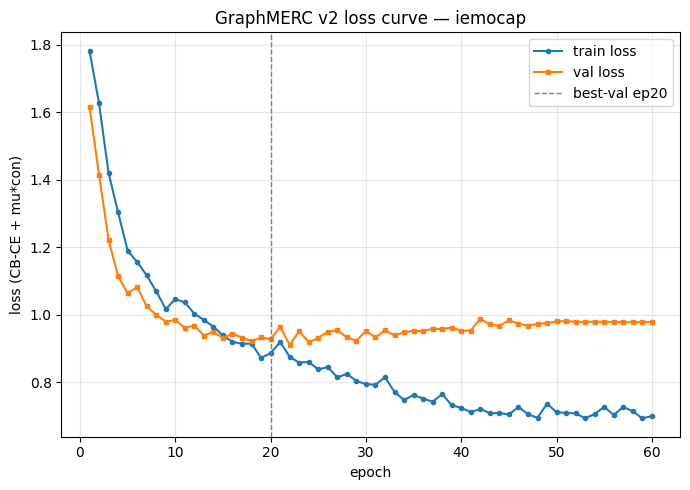

saved loss curve -> ./outputs/gmv2_iemocap_loss_curve.png


In [14]:
# --- Loss curve: train vs val ---
import matplotlib.pyplot as plt
if not RUN_R1:
    epochs_x = [h['epoch'] for h in history]
    plt.figure(figsize=(7, 5))
    plt.plot(epochs_x, [h['loss'] for h in history],     marker='o', ms=3, lw=1.5, label='train loss')
    plt.plot(epochs_x, [h['val_loss'] for h in history], marker='s', ms=3, lw=1.5, label='val loss')
    if best_val.get('epoch', -1) > 0:
        plt.axvline(best_val['epoch'], color='grey', ls='--', lw=1,
                    label=f"best-val ep{best_val['epoch']}")
    plt.xlabel('epoch'); plt.ylabel('loss (CB-CE + mu*con)')
    plt.title(f'GraphMERC v2 loss curve — {cfg.dataset}')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    out_png = os.path.join(cfg.save_dir, f'gmv2_{cfg.dataset}_loss_curve.png')
    plt.savefig(out_png, dpi=150, bbox_inches='tight'); plt.show()
    print('saved loss curve ->', out_png)


In [15]:
# --- Report with best-val and best-test checkpoints ---
if not RUN_R1:
    target_names = IEMO_NAMES if cfg.dataset == 'iemocap' else MELD_NAMES

    ckpt_val = torch.load(os.path.join(cfg.save_dir, f'gmv2_{cfg.dataset}_bestval.pt'),
                          map_location=device)
    model.load_state_dict(ckpt_val['state_dict'])
    acc, wf1, mf1, y_true, y_pred, _, _ = evaluate(model, test_loader)
    print(f'[BEST-VAL ckpt ep{ckpt_val["epoch"]}]  TEST acc={acc:.4f}  weighted-F1={wf1:.4f}  macro-F1={mf1:.4f}')
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_true, y_pred))

    print()

    ckpt_test = torch.load(os.path.join(cfg.save_dir, f'gmv2_{cfg.dataset}_besttest.pt'),
                           map_location=device)
    model.load_state_dict(ckpt_test['state_dict'])
    acc_bt, wf1_bt, mf1_bt, y_true_bt, y_pred_bt, _, _ = evaluate(model, test_loader)
    print(f'[BEST-TEST ckpt ep{ckpt_test["epoch"]}]  TEST acc={acc_bt:.4f}  weighted-F1={wf1_bt:.4f}  macro-F1={mf1_bt:.4f}')
    print(classification_report(y_true_bt, y_pred_bt, target_names=target_names, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_true_bt, y_pred_bt))


[BEST-VAL ckpt ep20]  TEST acc=0.6932  weighted-F1=0.6918  macro-F1=0.6782
              precision    recall  f1-score   support

         hap     0.6038    0.4444    0.5120       144
         sad     0.8856    0.7265    0.7982       245
         neu     0.6209    0.8359    0.7125       384
         ang     0.6571    0.6765    0.6667       170
         exc     0.7669    0.6823    0.7221       299
         fru     0.6788    0.6378    0.6576       381

    accuracy                         0.6932      1623
   macro avg     0.7022    0.6672    0.6782      1623
weighted avg     0.7036    0.6932    0.6918      1623

Confusion matrix:
[[ 64   5  21   1  51   2]
 [  4 178  30   1   0  32]
 [  9  10 321   3   7  34]
 [  0   0  10 115   0  45]
 [ 28   0  59   6 204   2]
 [  1   8  76  49   4 243]]

[BEST-TEST ckpt ep26]  TEST acc=0.7129  weighted-F1=0.7127  macro-F1=0.6994
              precision    recall  f1-score   support

         hap     0.5772    0.4931    0.5318       144
         sad   

In [16]:
# ── Output export ────────────────────────────────────────────────────────────
if not RUN_R1:
    import csv, datetime
    import seaborn as sns
    run_ts  = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    out_dir = os.path.join(cfg.save_dir, f'gmv2_run_{cfg.dataset}_{run_ts}')
    os.makedirs(out_dir, exist_ok=True)
    report_str = classification_report(y_true, y_pred, target_names=target_names, digits=4)
    with open(os.path.join(out_dir, 'classification_report.txt'), 'w') as f:
        f.write(f'GraphMERC v2 | Dataset: {cfg.dataset} | Run: {run_ts} | Epochs: {cfg.epochs}\n')
        f.write(f'schedule={cfg.schedule} cross_utt={cfg.cross_utt_inter} '
                f'con={cfg.contrastive} modDrop={cfg.mod_dropout_p} ls={cfg.label_smoothing}\n\n')
        f.write(f'[BEST-VAL ckpt — test]  acc={acc:.4f}  wF1={wf1:.4f}  mF1={mf1:.4f}\n\n')
        f.write(report_str)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(len(target_names)*1.1 + 1, len(target_names)*1.0 + 1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'GraphMERC v2 — {cfg.dataset} confusion (best-val ckpt)')
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.close(fig)
    if history:
        with open(os.path.join(out_dir, 'training_history.csv'), 'w', newline='') as f:
            w = csv.DictWriter(f, fieldnames=history[0].keys())
            w.writeheader(); w.writerows(history)
    print('exported ->', out_dir)


exported -> ./outputs/gmv2_run_iemocap_20260611_214615
